Desc: To predict the cliff distance (hdist where rel drops) for a given height, MCS, USI.

## Common imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle
from scipy.interpolate import make_interp_spline

def find_cliff_hdist(df, threshold):
    """
    Identify the 'cliff' point in the data where the value drops significantly.
    The cliff is defined as the horizontal distance where the reliability first drops below the threshold.

    Parameters:
    df (pd.DataFrame): DataFrame for a combination of height, USI, and Bitrate. The columns are 'Horizontal_Distance' and 'Reliability'.
    threshold (float): The reliability threshold (e.g., 0.99).

    Returns:
    hdist: The horizontal distance of the cliff point (where reliability first drops below threshold).
           Returns 0 if no cliff is found or all values are below threshold.
    """
    # Sort by horizontal distance to find the first point where reliability drops below threshold
    df_sorted = df.sort_values('Horizontal_Distance').reset_index(drop=True)
    
    if df_sorted.empty:
        return 0
    
    # Find the first index where reliability drops below threshold
    below_threshold = df_sorted[df_sorted['Reliability'] < threshold]
    
    if below_threshold.empty:
        # No point drops below threshold, return the max horizontal distance
        return df_sorted['Horizontal_Distance'].max()
    
    # Return the horizontal distance of the first point below threshold
    return below_threshold['Horizontal_Distance'].iloc[0]

def find_cliff_hdist_spline_interp(df, threshold, k_points = 5):
    """
    Identify the 'cliff' point in the data where the value drops significantly.
    The cliff is defined as the horizontal distance where the reliability first drops below the threshold.
    Spline interpolation: We use spline interp to find the cliff point with a finer resolution of 1 m.
    Interpolation is first used to find the reliability at a resolution of 1 m before finding the cliff point.

    Parameters:
    df (pd.DataFrame): DataFrame for a combination of height, USI, and Bitrate. The columns are 'Horizontal_Distance' and 'Reliability'.
    threshold (float): The reliability threshold (e.g., 0.99).
    k_points (int): The number of nearest points to use for finding the reliability at finer resolution.

    Returns:
    hdist: The horizontal distance of the cliff point (where reliability first drops below threshold).
           Returns 0 if no cliff is found or all values are below threshold.
    """
    # Sort by horizontal distance to find the first point where reliability drops below threshold
    df_sorted = df.sort_values('Horizontal_Distance').reset_index(drop=True)
    
    if df_sorted.empty:
        return 0
    
    # Create a finer resolution of horizontal distances (1 m)
    hdist_fine = np.arange(df_sorted['Horizontal_Distance'].min(), df_sorted['Horizontal_Distance'].max() + 1, 1)
    # Interpolate reliability at finer resolution using k-nearest neighbors but only for the points not already in df_sorted
    for h in hdist_fine:
        if h in df_sorted['Horizontal_Distance'].values:
            pred = df_sorted[df_sorted['Horizontal_Distance'] == h]['Reliability'].values[0]
        else:
            # Find the k nearest points in df_sorted
            distances = np.abs(df_sorted['Horizontal_Distance'] - h)
            nearest_indices = np.argpartition(distances, kth=k_points - 1)[:k_points]
            nearest_reliabilities = df_sorted.loc[nearest_indices, 'Reliability']
            nearest_hdist = df_sorted.loc[nearest_indices, 'Horizontal_Distance']
            
            # Perform localized interpolation using the nearest points
            x_local = nearest_hdist.values
            y_local = nearest_reliabilities.values
            # Spline requires sorted x
            order = np.argsort(x_local)
            x_local = x_local[order]
            y_local = y_local[order]
            if len(x_local) == 1:
                pred = y_local[0]
            elif len(x_local) == 2:
                # Linear interpolation fallback
                pred = np.interp(float(h), x_local, y_local)
            else:
                # With 3 points, quadratic spline (k=2), else cubic spline (k=3)
                k = 2 if len(x_local) == 3 else 3
                spline = make_interp_spline(x_local, y_local, k=k)
                # Keep local behavior; avoid extrapolation outside local window
                h_eval = float(np.clip(h, x_local.min(), x_local.max()))
                pred = float(spline(h_eval))
        
        # If predicted reliability is less than threshold, we can stop early since we are only interested in the cliff point
        if pred < threshold:
            return h - 1  # Return the last horizontal distance before dropping below threshold
        
    #         reliability_fine.append(float(np.clip(pred, 0.0, 1.0)))  # Ensure reliability is between 0 and 1
    
    # df_fine = pd.DataFrame({'Horizontal_Distance': hdist_fine, 'Reliability': reliability_fine})

    # # Find the first index where reliability drops below threshold in the finer resolution
    # below_threshold = df_fine[df_fine['Reliability'] < threshold]
    
    # if below_threshold.empty:
    #     # No point drops below threshold, return the max horizontal distance
    #     return df_fine['Horizontal_Distance'].max()
    
    # # Return the horizontal distance of the first point below threshold
    # return below_threshold['Horizontal_Distance'].iloc[0]

def interp_reliability(df, k_points = 3):
    """
    Identify the 'cliff' point in the data where the value drops significantly.
    The cliff is defined as the horizontal distance where the reliability first drops below the threshold.
    Spline interpolation: We use spline interp to find the cliff point with a finer resolution of 1 m.
    Interpolation is first used to find the reliability at a resolution of 1 m before finding the cliff point.

    Parameters:
    df (pd.DataFrame): DataFrame for a combination of height, USI, and Bitrate. The columns are 'Horizontal_Distance' and 'Reliability'.
    threshold (float): The reliability threshold (e.g., 0.99).
    k_points (int): The number of nearest points to use for finding the reliability at finer resolution.

    Returns:
    hdist: The horizontal distance of the cliff point (where reliability first drops below threshold).
           Returns 0 if no cliff is found or all values are below threshold.
    """
    # Sort by horizontal distance to find the first point where reliability drops below threshold
    df_sorted = df.sort_values('Horizontal_Distance').reset_index(drop=True)
    
    if df_sorted.empty:
        return 0
    
    # Create a finer resolution of horizontal distances (1 m)
    hdist_fine = np.arange(df_sorted['Horizontal_Distance'].min(), df_sorted['Horizontal_Distance'].max() + 1, 1)
    # Interpolate reliability at finer resolution using k-nearest neighbors but only for the points not already in df_sorted
    reliability_fine = []
    for h in hdist_fine:
        if h in df_sorted['Horizontal_Distance'].values:
            pred = df_sorted[df_sorted['Horizontal_Distance'] == h]['Reliability'].values[0]
        else:
            # Find the k nearest points in df_sorted
            distances = np.abs(df_sorted['Horizontal_Distance'] - h)
            nearest_indices = np.argpartition(distances, kth=k_points - 1)[:k_points]
            nearest_reliabilities = df_sorted.loc[nearest_indices, 'Reliability']
            nearest_hdist = df_sorted.loc[nearest_indices, 'Horizontal_Distance']
            
            # Perform localized interpolation using the nearest points
            x_local = nearest_hdist.values
            y_local = nearest_reliabilities.values
            # Spline requires sorted x
            order = np.argsort(x_local)
            x_local = x_local[order]
            y_local = y_local[order]
            if len(x_local) == 1:
                pred = y_local[0]
            elif len(x_local) == 2:
                # Linear interpolation fallback
                pred = np.interp(float(h), x_local, y_local)
            else:
                # With 3 points, quadratic spline (k=2), else cubic spline (k=3)
                k = 2 if len(x_local) == 3 else 3
                spline = make_interp_spline(x_local, y_local, k=k)
                # Keep local behavior; avoid extrapolation outside local window
                h_eval = float(np.clip(h, x_local.min(), x_local.max()))
                pred = float(spline(h_eval))
        
        reliability_fine.append(float(np.clip(pred, 0.0, 1.0)))  # Ensure reliability is between 0 and 1
    
    df_fine = pd.DataFrame({'Horizontal_Distance': hdist_fine, 'Reliability': reliability_fine})
    return df_fine

## Quadratic Fit <br>
Input: Height <br>
NOTE: Different model trained for each combination of MCS, USI

In [57]:
link = "Video" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [60, 90, 120, 150, 180, 210, 240, 270, 300]
# Training Dataset Path
dataset_file_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/data_processed/{link}_Reliability.csv"
# Save Model Path
save_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/quadratic_fit_cliff_dist/{link.lower()}/"

os.makedirs(save_path, exist_ok=True)
data_df = pd.read_csv(dataset_file_path)
cliff_dist_dict = {} 

if "Num_Sent" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / data_df["Num_Sent"]
elif "Num_Fail_Other" in data_df.columns and "Num_Delay_Excd" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / (data_df["Num_Reliable"] + data_df["Num_Delay_Excd"] + data_df["Num_Fail_Other"])
    
for usi in USI:
    for bitrate in BITRATE:
        cliff_hdist_list = []
        for height in HEIGHT:
            subset = data_df[(data_df['UAV_Sending_Interval'] == usi) & (data_df['Bitrate'] == bitrate) & (data_df['Height'] == height)]
            cliff_hdist_list.append(find_cliff_hdist(subset, threshold=0.99))
        if any(hdist > 0 for hdist in cliff_hdist_list):
            cliff_dist_dict[(usi, bitrate)] = cliff_hdist_list

# Quadratic Fitting
X = HEIGHT
for (usi, bitrate), cliff_hdist_list in cliff_dist_dict.items():
    y = cliff_hdist_list
    coeffs_2d = np.polyfit(X, y, deg=2)
    # quadratic_fit = np.poly1d(coeffs_2d)
    
    # Save the quadratic fit coefficients
    np.save(os.path.join(save_path, f"quadratic_fit_deg_2_usi_{usi}_bitrate_{bitrate}.npy"), coeffs_2d)


In [13]:
# Testing

link = "Uplink" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [75, 105, 135, 165, 195, 225, 255, 285]
# Testing Dataset Path
test_dataset_file_path = f"/media/research-student/DataDrive/FANET_Dataset/Dataset_NP100000_DJISpark/complete_testing_dmax_dataset/data_processed_complete/{link}_Reliability.csv"
test_data_df = pd.read_csv(test_dataset_file_path)
# Polynomial Fit Coefficients Path
quadratic_fit_coeffs_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/quadratic_fit_cliff_dist/{link.lower()}/"


# Get reliability from the test dataset
if "Num_Sent" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / test_data_df["Num_Sent"]
elif "Num_Fail_Other" in test_data_df.columns and "Num_Delay_Excd" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / (test_data_df["Num_Reliable"] + test_data_df["Num_Delay_Excd"] + test_data_df["Num_Fail_Other"])
    
results = []
for usi in USI:
    for bitrate in BITRATE:
        if link == "Uplink" and usi == 66.7 and bitrate == 6.5:
            continue # An exception is required for this case
        cliff_hdist_list = []
        for height in HEIGHT:
            # Get the ground truth cliff horizontal distance from the test dataset
            subset = test_data_df[(test_data_df['UAV_Sending_Interval'] == usi) & (test_data_df['Bitrate'] == bitrate) & (test_data_df['Height'] == height)]
            cliff_hdist_list.append(find_cliff_hdist(subset, threshold=0.99))
        if any(hdist > 0 for hdist in cliff_hdist_list):
            # Evaluate the quadratic fit model on the test dataset, but only if there is an actual cliff (hdist > 0) in the test dataset for that combination of USI and Bitrate. This ensures we are evaluating the model on relevant data points.
            coeffs_2d = np.load(os.path.join(quadratic_fit_coeffs_path, f"quadratic_fit_deg_2_usi_{usi}_bitrate_{bitrate}.npy"))
            quadratic_fit = np.poly1d(coeffs_2d)
            for height, cliff_hdist in zip(HEIGHT, cliff_hdist_list):
                predicted_cliff_hdist = quadratic_fit(height)
                predicted_cliff_hdist = max(predicted_cliff_hdist, 0) # Ensure non-negative predictions
                results.append({
                    "USI": usi,
                    "Bitrate": bitrate,
                    "Height": height,
                    "Ground Truth Cliff Hdist": cliff_hdist,
                    "Predicted Cliff Hdist": predicted_cliff_hdist
                })

results_df = pd.DataFrame(results)
# Evaluate metrics such as Mean Absolute Error (MAE) or Root Mean Squared Error (RMSE) between the predicted and ground truth cliff horizontal distances
err = np.array(results_df["Ground Truth Cliff Hdist"].tolist()) - np.array(results_df["Predicted Cliff Hdist"].tolist())
percent_err = np.abs(err) / np.array(results_df["Ground Truth Cliff Hdist"].tolist()) * 100
mean_percent_err = np.mean(percent_err, where=np.array(results_df["Ground Truth Cliff Hdist"].tolist()) != 0) # Avoid division by zero
abs_err = np.abs(err)
mae = np.mean(abs_err)
std_abs_err = np.std(abs_err)
mse = np.mean(err**2)
max_ae = np.max(abs_err)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Standard Deviation of Absolute Error: {std_abs_err}")
print(f"Mean Percentage Error: {mean_percent_err}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Max Absolute Error: {max_ae}")

# Find where error is the max
max_err_index = np.argmax(abs_err)
print("Combination with Max Absolute Error:")
print(results_df.iloc[max_err_index])

Mean Absolute Error (MAE): 6.947326111388628
Standard Deviation of Absolute Error: 8.28712577151666
Mean Percentage Error: 18.59587095443654
Mean Squared Error (MSE): 116.94179365091783
Max Absolute Error: 38.198051948051884
Combination with Max Absolute Error:
USI                          10.000000
Bitrate                      39.000000
Height                      255.000000
Ground Truth Cliff Hdist      0.000000
Predicted Cliff Hdist        38.198052
Name: 14, dtype: float64


/tmp/ipykernel_1488810/196441256.py:48: RuntimeWarning: divide by zero encountered in divide
  percent_err = np.abs(err) / np.array(results_df["Ground Truth Cliff Hdist"].tolist()) * 100
/tmp/ipykernel_1488810/196441256.py:48: RuntimeWarning: invalid value encountered in divide
  percent_err = np.abs(err) / np.array(results_df["Ground Truth Cliff Hdist"].tolist()) * 100


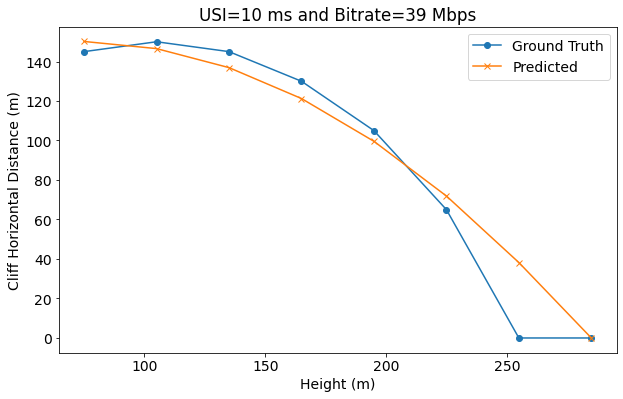

In [14]:
# Plot results
USI = 10
BITRATE = 39
subset_results = results_df[(results_df['USI'] == USI) & (results_df['Bitrate'] == BITRATE)]
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 14})
plt.plot(subset_results['Height'], subset_results['Ground Truth Cliff Hdist'], marker='o', label='Ground Truth')
plt.plot(subset_results['Height'], subset_results['Predicted Cliff Hdist'], marker='x', label='Predicted')
plt.title(f'USI={USI} ms and Bitrate={BITRATE} Mbps')
plt.xlabel('Height (m)')
plt.ylabel('Cliff Horizontal Distance (m)')
plt.legend()

## Support Vector Machine (For Inputs of USI, MCS)

In [ ]:
# Training SVR Model (Height only) - One model per USI and Bitrate combination
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import pickle

link = "Downlink" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [60, 90, 120, 150, 180, 210, 240, 270, 300]

dataset_file_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/data_processed/{link}_Reliability.csv"
save_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/svr_cliff_dist_height_only/{link.lower()}/"

os.makedirs(save_path, exist_ok=True)
data_df = pd.read_csv(dataset_file_path)

if "Num_Sent" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / data_df["Num_Sent"]
elif "Num_Fail_Other" in data_df.columns and "Num_Delay_Excd" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / (data_df["Num_Reliable"] + data_df["Num_Delay_Excd"] + data_df["Num_Fail_Other"])

for usi in USI:
    for bitrate in BITRATE:
        X_train = []
        y_train = []
        
        for height in HEIGHT:
            subset = data_df[(data_df['UAV_Sending_Interval'] == usi) & (data_df['Bitrate'] == bitrate) & (data_df['Height'] == height)]
            cliff_hdist = find_cliff_hdist(subset, threshold=0.99)
            X_train.append([height])
            y_train.append(cliff_hdist)
        
        if len(X_train) == 0:
            print(f"Skipping USI={usi}, Bitrate={bitrate}: No valid cliff distances")
            continue
        
        X_train = np.array(X_train)
        y_train = np.array(y_train)
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        
        param_grid = {
            'C': [10, 100, 1000, 10000, 100000],
            'epsilon': [0.01, 0.001, 0.0001, 0.00001, 0.000001],
            'gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1]
        }
        cv = [(slice(None), slice(None))]  # Disable cross-validation
        
        # Use cv=None to disable cross-validation and train/validate on the same data
        svr = SVR(kernel='rbf')
        grid_search = GridSearchCV(svr, param_grid, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=0)
        grid_search.fit(X_train_scaled, y_train)
        
        svr_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        
        # Calculate MAE on training data (same data used for training)
        train_predictions = svr_model.predict(X_train_scaled)
        train_mae = np.mean(np.abs(y_train - train_predictions))
        
        print(f"USI={usi}, Bitrate={bitrate}")
        print(f"  Best parameters: {best_params}")
        print(f"  Training MAE: {train_mae:.4f}")
        print(f"  Training samples: {len(X_train)}\n")
        
        # Save the SVR model and scaler
        model_filename = f"svr_model_usi_{usi}_bitrate_{bitrate}.pkl"
        scaler_filename = f"scaler_usi_{usi}_bitrate_{bitrate}.pkl"
        params_filename = f"best_params_usi_{usi}_bitrate_{bitrate}.txt"
        
        pickle.dump(svr_model, open(os.path.join(save_path, model_filename), 'wb'))
        pickle.dump(scaler, open(os.path.join(save_path, scaler_filename), 'wb'))
        
        with open(os.path.join(save_path, params_filename), 'w') as f:
            f.write(f"Best Parameters for USI={usi}, Bitrate={bitrate}:\n")
            for param, value in best_params.items():
                f.write(f"{param}: {value}\n")
            f.write(f"\nTraining MAE: {train_mae:.4f}\n")
            f.write(f"Training samples: {len(X_train)}\n")

print(f"All models saved to {save_path}")

USI=10, Bitrate=6.5
  Best parameters: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
  Training MAE: 0.0000
  Training samples: 9

USI=10, Bitrate=13
  Best parameters: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
  Training MAE: 0.0000
  Training samples: 9

USI=10, Bitrate=19.5
  Best parameters: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
  Training MAE: 0.0000
  Training samples: 9

USI=10, Bitrate=26
  Best parameters: {'C': 100000, 'epsilon': 0.0001, 'gamma': 'scale'}
  Training MAE: 0.0001
  Training samples: 9

USI=10, Bitrate=39
  Best parameters: {'C': 100000, 'epsilon': 0.0001, 'gamma': 'scale'}
  Training MAE: 0.0002
  Training samples: 9

USI=10, Bitrate=52
  Best parameters: {'C': 100000, 'epsilon': 0.001, 'gamma': 'auto'}
  Training MAE: 0.0004
  Training samples: 9

USI=10, Bitrate=58.5
  Best parameters: {'C': 100000, 'epsilon': 0.001, 'gamma': 'auto'}
  Training MAE: 0.0002
  Training samples: 9

USI=10, Bitrate=65
  Best parameters: {'C': 100000, 'epsilon': 0.001, 'g

In [23]:
# Testing SVR Model (Height only) - Load per-combination models
link = "Video" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [75, 105, 135, 165, 195, 225, 255, 285]

# Testing Dataset Path
test_dataset_file_path = f"/media/research-student/DataDrive/FANET_Dataset/Dataset_NP100000_DJISpark/complete_testing_dmax_dataset/data_processed_complete/{link}_Reliability.csv"
test_data_df = pd.read_csv(test_dataset_file_path)

# SVR Model Path
svr_model_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/svr_cliff_dist_height_only/{link.lower()}/"

# Get reliability from the test dataset
if "Num_Sent" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / test_data_df["Num_Sent"]
elif "Num_Fail_Other" in test_data_df.columns and "Num_Delay_Excd" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / (test_data_df["Num_Reliable"] + test_data_df["Num_Delay_Excd"] + test_data_df["Num_Fail_Other"])

results = []
for usi in USI:
    for bitrate in BITRATE:
        if link == "Uplink" and usi == 66.7 and bitrate == 6.5:
            continue # An exception is required for this case
        
        # Load the SVR model and scaler for this USI/Bitrate combination
        model_filename = f"svr_model_usi_{usi}_bitrate_{bitrate}.pkl"
        scaler_filename = f"scaler_usi_{usi}_bitrate_{bitrate}.pkl"
        
        model_path = os.path.join(svr_model_path, model_filename)
        scaler_path = os.path.join(svr_model_path, scaler_filename)
        
        # Skip if model doesn't exist for this combination
        if not os.path.exists(model_path):
            print(f"Skipping USI={usi}, Bitrate={bitrate}: Model file not found")
            continue
        
        svr_model = pickle.load(open(model_path, 'rb'))
        scaler = pickle.load(open(scaler_path, 'rb'))
        
        cliff_hdist_list = []
        for height in HEIGHT:
            # Get the ground truth cliff horizontal distance from the test dataset
            subset = test_data_df[(test_data_df['UAV_Sending_Interval'] == usi) & (test_data_df['Bitrate'] == bitrate) & (test_data_df['Height'] == height)]
            cliff_hdist_list.append(find_cliff_hdist(subset, threshold=0.99))
        
        if any(hdist > 0 for hdist in cliff_hdist_list):
            # Evaluate the SVR model on the test dataset
            for height, cliff_hdist in zip(HEIGHT, cliff_hdist_list):
                X_test = np.array([[height]])
                X_test_scaled = scaler.transform(X_test)
                predicted_cliff_hdist = svr_model.predict(X_test_scaled)[0]
                predicted_cliff_hdist = max(predicted_cliff_hdist, 0)
                results.append({
                    "USI": usi,
                    "Bitrate": bitrate,
                    "Height": height,
                    "Ground Truth Cliff Hdist": cliff_hdist,
                    "Predicted Cliff Hdist": predicted_cliff_hdist
                })

results_df = pd.DataFrame(results)

# Evaluate metrics
err = np.array(results_df["Ground Truth Cliff Hdist"].tolist()) - np.array(results_df["Predicted Cliff Hdist"].tolist())
percent_err = np.abs(err) / np.array(results_df["Ground Truth Cliff Hdist"].tolist()) * 100
mean_percent_err = np.mean(percent_err, where=np.array(results_df["Ground Truth Cliff Hdist"].tolist()) != 0) # Avoid division by zero
abs_err = np.abs(err)
mae = np.mean(abs_err)
std_abs_err = np.std(abs_err)
mse = np.mean(err**2)
max_ae = np.max(abs_err)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Standard Deviation of Absolute Error: {std_abs_err}")
print(f"Mean Percentage Error: {mean_percent_err}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Max Absolute Error: {max_ae}")

# Find where error is the max
max_err_index = np.argmax(abs_err)
print("\nCombination with Max Absolute Error:")
print(results_df.iloc[max_err_index])

Mean Absolute Error (MAE): 3.8391631987432553
Standard Deviation of Absolute Error: 4.108897096320015
Mean Percentage Error: 5.400348045048842
Mean Squared Error (MSE): 31.62220941473159
Max Absolute Error: 23.678200421664016

Combination with Max Absolute Error:
USI                          20.0000
Bitrate                      39.0000
Height                      285.0000
Ground Truth Cliff Hdist      0.0000
Predicted Cliff Hdist        23.6782
Name: 71, dtype: float64


/tmp/ipykernel_1488810/65409441.py:66: RuntimeWarning: divide by zero encountered in divide
  percent_err = np.abs(err) / np.array(results_df["Ground Truth Cliff Hdist"].tolist()) * 100
/tmp/ipykernel_1488810/65409441.py:66: RuntimeWarning: invalid value encountered in divide
  percent_err = np.abs(err) / np.array(results_df["Ground Truth Cliff Hdist"].tolist()) * 100


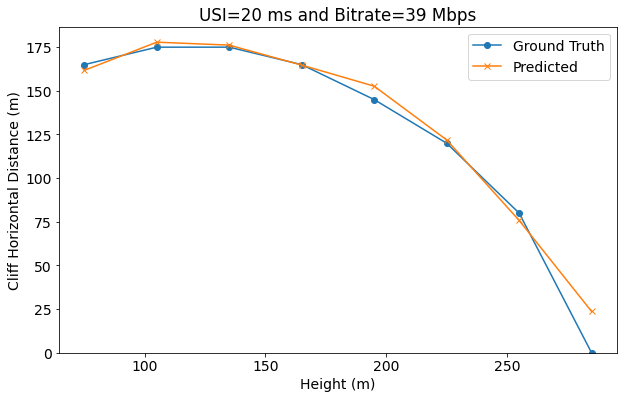

In [24]:
# Plot results
USI = 20
BITRATE = 39
subset_results = results_df[(results_df['USI'] == USI) & (results_df['Bitrate'] == BITRATE)]
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 14})
plt.plot(subset_results['Height'], subset_results['Ground Truth Cliff Hdist'], marker='o', label='Ground Truth')
plt.plot(subset_results['Height'], subset_results['Predicted Cliff Hdist'], marker='x', label='Predicted')
plt.title(f'USI={USI} ms and Bitrate={BITRATE} Mbps')
plt.xlabel('Height (m)')
plt.ylabel('Cliff Horizontal Distance (m)')
plt.ylim(0)
plt.legend()

## Support Vector Regression (For Inputs of Height, USI, MCS)

In [17]:
# Training SVR Model
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import pickle

# Training SVR Model
link = "Video" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [60, 90, 120, 150, 180, 210, 240, 270, 300]

# Training Dataset Path
dataset_file_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/data_processed/{link}_Reliability.csv"
# Save Model Path
save_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/svr_cliff_dist/{link.lower()}/"

os.makedirs(save_path, exist_ok=True)
data_df = pd.read_csv(dataset_file_path)

# Calculate reliability
if "Num_Sent" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / data_df["Num_Sent"]
elif "Num_Fail_Other" in data_df.columns and "Num_Delay_Excd" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / (data_df["Num_Reliable"] + data_df["Num_Delay_Excd"] + data_df["Num_Fail_Other"])

# Collect all training data across USI and Bitrate combinations
X_train = []
y_train = []

for usi in USI:
    for bitrate in BITRATE:
        cliff_hdist_list = []
        for height in HEIGHT:
            subset = data_df[(data_df['UAV_Sending_Interval'] == usi) & (data_df['Bitrate'] == bitrate) & (data_df['Height'] == height)]
            cliff_hdist = find_cliff_hdist(subset, threshold=0.99)
            cliff_hdist_list.append(cliff_hdist)
            # if cliff_hdist >s 0:  # Only add valid cliff distances
                # X_train.append([height, usi, bitrate])
                # y_train.append(cliff_hdist)
            X_train.append([height, usi, bitrate])
            y_train.append(cliff_hdist)

X_train = np.array(X_train)
y_train = np.array(y_train)

# Standardize features for SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

""" Fitting with RBF Kernel SVR """
# Define parameter grid for GridSearchCV
param_grid = {
    'C': [10, 100, 1000, 10000, 100000],
    'epsilon': [0.0001, 0.00001, 0.000001, 1e-7, 1e-8, 1e-9],
    'gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1]
}
# Perform GridSearchCV with 5-fold cross-validation
svr = SVR(kernel='rbf')
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

# """ Fitting with poly Kernel SVR """
# # Define parameter grid for GridSearchCV
# param_grid = {
#     'degree': [2, 3],
#     'C': [10, 100, 1000, 10000],
#     'epsilon': [0.1, 0.01, 0.001, 0.0001, 0.00001],
#     'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
# }
# # Perform GridSearchCV with 5-fold cross-validation
# svr = SVR(kernel='poly')
# grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)
# grid_search.fit(X_train_scaled, y_train)

# Get best model
svr_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f"Best parameters: {best_params}")
print(f"Best CV MAE: {-grid_search.best_score_:.4f}")
print(f"SVR model trained on {len(X_train)} samples")

# Save the best SVR model and scaler
pickle.dump(svr_model, open(os.path.join(save_path, "svr_model.pkl"), 'wb'))
pickle.dump(scaler, open(os.path.join(save_path, "scaler.pkl"), 'wb'))

# Save best parameters to a file for reference
with open(os.path.join(save_path, "best_params.txt"), 'w') as f:
    f.write(f"Best Parameters:\n")
    for param, value in best_params.items():
        f.write(f"{param}: {value}\n")
    f.write(f"\nBest CV MAE: {-grid_search.best_score_:.4f}\n")

print(f"Model saved to {save_path}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best parameters: {'C': 100, 'epsilon': 1e-06, 'gamma': 'auto'}
Best CV MAE: 73.2156
SVR model trained on 288 samples
Model saved to /media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/svr_cliff_dist/video/


In [18]:
# Testing SVR Model
link = "Video" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [75, 105, 135, 165, 195, 225, 255, 285]

# Testing Dataset Path
test_dataset_file_path = f"/media/research-student/DataDrive/FANET_Dataset/Dataset_NP100000_DJISpark/complete_testing_dmax_dataset/data_processed_complete/{link}_Reliability.csv"
test_data_df = pd.read_csv(test_dataset_file_path)

# SVR Model Path
svr_model_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/svr_cliff_dist/{link.lower()}/"

# Get reliability from the test dataset
if "Num_Sent" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / test_data_df["Num_Sent"]
elif "Num_Fail_Other" in test_data_df.columns and "Num_Delay_Excd" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / (test_data_df["Num_Reliable"] + test_data_df["Num_Delay_Excd"] + test_data_df["Num_Fail_Other"])

# Load the SVR model and scaler
svr_model = pickle.load(open(os.path.join(svr_model_path, "svr_model.pkl"), 'rb'))
scaler = pickle.load(open(os.path.join(svr_model_path, "scaler.pkl"), 'rb'))

results = []
for usi in USI:
    for bitrate in BITRATE:
        cliff_hdist_list = []
        for height in HEIGHT:
            # Get the ground truth cliff horizontal distance from the test dataset
            subset = test_data_df[(test_data_df['UAV_Sending_Interval'] == usi) & (test_data_df['Bitrate'] == bitrate) & (test_data_df['Height'] == height)]
            cliff_hdist_list.append(find_cliff_hdist(subset, threshold=0.99))
        if any(hdist > 0 for hdist in cliff_hdist_list):
            # Evaluate the SVR model on the test dataset
            for height, cliff_hdist in zip(HEIGHT, cliff_hdist_list):
                X_test = np.array([[height, usi, bitrate]])
                X_test_scaled = scaler.transform(X_test)
                predicted_cliff_hdist = svr_model.predict(X_test_scaled)[0]
                results.append({
                    "USI": usi,
                    "Bitrate": bitrate,
                    "Height": height,
                    "Ground Truth Cliff Hdist": cliff_hdist,
                    "Predicted Cliff Hdist": predicted_cliff_hdist
                })

results_df = pd.DataFrame(results)

# Evaluate metrics
err = np.array(results_df["Ground Truth Cliff Hdist"].tolist()) - np.array(results_df["Predicted Cliff Hdist"].tolist())
abs_err = np.abs(err)
mae = np.mean(abs_err)
mse = np.mean(err**2)
rmse = np.sqrt(mse)
max_ae = np.max(abs_err)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Max Absolute Error: {max_ae:.4f}")

# Find where error is the max
max_err_index = np.argmax(abs_err)
print("\nCombination with Max Absolute Error:")
print(results_df.iloc[max_err_index])

Mean Absolute Error (MAE): 27.7778
Mean Squared Error (MSE): 3308.1406
Root Mean Squared Error (RMSE): 57.5164
Max Absolute Error: 308.6274

Combination with Max Absolute Error:
USI                          20.000000
Bitrate                      13.000000
Height                      285.000000
Ground Truth Cliff Hdist    420.000000
Predicted Cliff Hdist       111.372578
Name: 47, dtype: float64


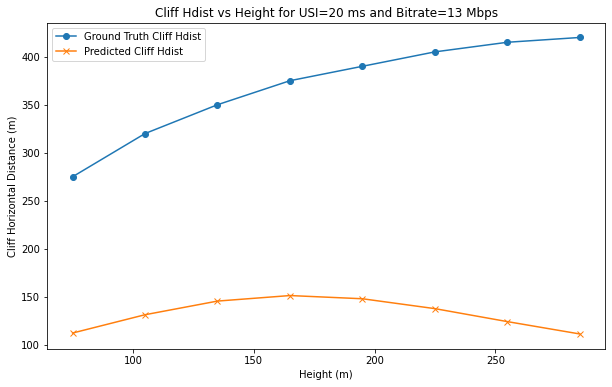

In [19]:
# Plot results
USI = 20
BITRATE = 13
subset_results = results_df[(results_df['USI'] == USI) & (results_df['Bitrate'] == BITRATE)]
plt.figure(figsize=(10, 6))
plt.plot(subset_results['Height'], subset_results['Ground Truth Cliff Hdist'], marker='o', label='Ground Truth Cliff Hdist')
plt.plot(subset_results['Height'], subset_results['Predicted Cliff Hdist'], marker='x', label='Predicted Cliff Hdist')
plt.title(f'Cliff Hdist vs Height for USI={USI} ms and Bitrate={BITRATE} Mbps')
plt.xlabel('Height (m)')
plt.ylabel('Cliff Horizontal Distance (m)')
plt.legend()

## Spline Interpolation (For Inputs of USI, MCS)

In [19]:
# Spline interpolation (Height-only), one model per (USI, Bitrate)
# Assumes find_cliff_hdist(...) is already defined in an earlier cell.

from scipy.interpolate import make_interp_spline

# -----------------------------
# Config
# -----------------------------
link = "Video"  # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]  # treat as MCS
TRAIN_HEIGHT = [60, 90, 120, 150, 180, 210, 240, 270, 300]
TEST_HEIGHT = [75, 105, 135, 165, 195, 225, 255, 285]
THRESHOLD = 0.99

train_dataset_file_path = (
    f"/media/research-student/DataDrive/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/train_dataset_processed/{link}_Reliability.csv"
)
# test_dataset_file_path = (
#     f"/media/research-student/DataDrive/FANET_Dataset/"
#     f"Dataset_NP100000_DJISpark/complete_testing_dmax_dataset/"
#     f"data_processed_complete/{link}_Reliability.csv"
# )
test_dataset_file_path = (
    f"/media/research-student/DataDrive/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/test_dataset_processed/{link}_Reliability.csv"
)
save_path = (
    f"/media/research-student/KingstonSSD/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/spline_cliff_dist_height_only/{link.lower()}/"
)

os.makedirs(save_path, exist_ok=True)

def add_reliability(df: pd.DataFrame) -> pd.DataFrame:
    if "Num_Sent" in df.columns and "Num_Reliable" in df.columns:
        df["Reliability"] = df["Num_Reliable"] / df["Num_Sent"]
    elif all(c in df.columns for c in ["Num_Fail_Other", "Num_Delay_Excd", "Num_Reliable"]):
        df["Reliability"] = df["Num_Reliable"] / (
            df["Num_Reliable"] + df["Num_Delay_Excd"] + df["Num_Fail_Other"]
        )
    else:
        raise ValueError("Required columns for Reliability not found.")
    return df

def combo_subset(df: pd.DataFrame, usi: float, bitrate: float, height: float) -> pd.DataFrame:
    return df.loc[(df["UAV_Sending_Interval"].to_numpy(dtype=float) == usi) & 
                  (df["Bitrate"].to_numpy(dtype=float) == bitrate) & (df["Height"].to_numpy(dtype=float) == height) &
                  (df["Height"].to_numpy(dtype=float) == height)]
# -----------------------------
# Train spline per (USI, Bitrate)
# -----------------------------
train_df = add_reliability(pd.read_csv(train_dataset_file_path))

for usi in USI:
    for bitrate in BITRATE:
        x_train, y_train = [], []

        for h in TRAIN_HEIGHT:
            subset = combo_subset(train_df, usi, bitrate, h)
            cliff_hdist = find_cliff_hdist(subset, threshold=THRESHOLD)
            x_train.append(float(h))
            y_train.append(float(cliff_hdist))

        x_train = np.array(x_train, dtype=float)
        y_train = np.array(y_train, dtype=float)

        # Skip combos with no meaningful cliff distance
        if not np.any(y_train > 0):
            print(f"Skipping USI={usi}, Bitrate={bitrate}: no valid cliff distances")
            continue

        # Ensure sorted unique x (required by spline)
        xy = (
            pd.DataFrame({"x": x_train, "y": y_train})
            .groupby("x", as_index=False)["y"]
            .mean()
            .sort_values("x")
        )
        x_u = xy["x"].to_numpy(dtype=float)
        y_u = xy["y"].to_numpy(dtype=float)

        if len(x_u) < 2:
            print(f"Skipping USI={usi}, Bitrate={bitrate}: insufficient points for spline")
            continue

        # Cubic when possible; fallback to lower order if needed
        k = min(3, len(x_u) - 1)
        spline_model = make_interp_spline(x_u, y_u, k=k)

        model_file = os.path.join(save_path, f"spline_model_usi_{usi}_bitrate_{bitrate}.pkl")
        with open(model_file, "wb") as f:
            pickle.dump(
                {
                    "spline": spline_model,
                    "x_min": float(x_u.min()),
                    "x_max": float(x_u.max()),
                    "k": int(k),
                },
                f,
            )

        print(f"Saved spline: USI={usi}, Bitrate={bitrate}, k={k}")

print(f"\nAll spline models saved to {save_path}")

# -----------------------------
# Test per (USI, Bitrate)
# -----------------------------
test_df = add_reliability(pd.read_csv(test_dataset_file_path))

results = []
for usi in USI:
    for bitrate in BITRATE:
        if link == "Uplink" and usi == 66.7 and bitrate == 6.5:
            continue  # keep your original exception

        model_file = os.path.join(save_path, f"spline_model_usi_{usi}_bitrate_{bitrate}.pkl")
        if not os.path.exists(model_file):
            print(f"Skipping USI={usi}, Bitrate={bitrate}: model not found")
            continue

        with open(model_file, "rb") as f:
            obj = pickle.load(f)

        spline_model = obj["spline"]
        x_min, x_max = obj["x_min"], obj["x_max"]

        gt_list = []
        for h in TEST_HEIGHT:
            subset = combo_subset(test_df, usi, bitrate, h)
            gt_list.append(find_cliff_hdist(subset, threshold=THRESHOLD))

        if any(hd > 0 for hd in gt_list):
            for h, gt in zip(TEST_HEIGHT, gt_list):
                # Clip to train range to avoid risky extrapolation
                h_eval = float(np.clip(h, x_min, x_max))
                pred = float(spline_model(h_eval))
                pred = max(pred, 0.0)

                results.append(
                    {
                        "USI": usi,
                        "Bitrate": bitrate,
                        "Height": h,
                        "Ground Truth Cliff Hdist": float(gt),
                        "Predicted Cliff Hdist": pred,
                    }
                )

results_df = pd.DataFrame(results)

# Evaluate  metrics in the cell "Evaluate Metrics", make sure results are stored in results_df with columns "Ground Truth Cliff Hdist" and "Predicted Cliff Hdist"

# if results_df.empty:
#     print("No test results were generated.")
# else:
#     gt = results_df["Ground Truth Cliff Hdist"].to_numpy(dtype=float)
#     pred = results_df["Predicted Cliff Hdist"].to_numpy(dtype=float)

#     err = gt - pred
#     abs_err = np.abs(err)
#     mse = np.mean(err**2)
#     mae = np.mean(abs_err)
#     std_abs_err = np.std(abs_err)
#     max_ae = np.max(abs_err)

#     with np.errstate(divide="ignore", invalid="ignore"):
#         percent_err = np.where(gt != 0, abs_err / gt * 100, np.nan)
#     mean_percent_err = np.nanmean(percent_err)

#     print(f"Mean Absolute Error (MAE): {mae:.4f}")
#     print(f"Standard Deviation of Absolute Error: {std_abs_err:.4f}")
#     print(f"Mean Percentage Error: {mean_percent_err:.4f}")
#     print(f"Mean Squared Error (MSE): {mse:.4f}")
#     print(f"Max Absolute Error: {max_ae:.4f}")

#     max_err_index = int(np.argmax(abs_err))
#     print("\nCombination with Max Absolute Error:")
#     print(results_df.iloc[max_err_index])

Skipping USI=10, Bitrate=6.5: no valid cliff distances
Skipping USI=10, Bitrate=13: no valid cliff distances
Skipping USI=10, Bitrate=19.5: no valid cliff distances
Saved spline: USI=10, Bitrate=26, k=3
Saved spline: USI=10, Bitrate=39, k=3
Saved spline: USI=10, Bitrate=52, k=3
Saved spline: USI=10, Bitrate=58.5, k=3
Saved spline: USI=10, Bitrate=65, k=3
Skipping USI=20, Bitrate=6.5: no valid cliff distances
Saved spline: USI=20, Bitrate=13, k=3
Saved spline: USI=20, Bitrate=19.5, k=3
Saved spline: USI=20, Bitrate=26, k=3
Saved spline: USI=20, Bitrate=39, k=3
Saved spline: USI=20, Bitrate=52, k=3
Saved spline: USI=20, Bitrate=58.5, k=3
Saved spline: USI=20, Bitrate=65, k=3
Saved spline: USI=66.7, Bitrate=6.5, k=3
Saved spline: USI=66.7, Bitrate=13, k=3
Saved spline: USI=66.7, Bitrate=19.5, k=3
Saved spline: USI=66.7, Bitrate=26, k=3
Saved spline: USI=66.7, Bitrate=39, k=3
Saved spline: USI=66.7, Bitrate=52, k=3
Saved spline: USI=66.7, Bitrate=58.5, k=3
Saved spline: USI=66.7, Bitrate=6

Saved spline: USI=100, Bitrate=13, k=3
Saved spline: USI=100, Bitrate=19.5, k=3
Saved spline: USI=100, Bitrate=26, k=3
Saved spline: USI=100, Bitrate=39, k=3
Saved spline: USI=100, Bitrate=52, k=3
Saved spline: USI=100, Bitrate=58.5, k=3
Saved spline: USI=100, Bitrate=65, k=3

All spline models saved to /media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/spline_cliff_dist_height_only/video/
Skipping USI=10, Bitrate=6.5: model not found
Skipping USI=10, Bitrate=13: model not found
Skipping USI=10, Bitrate=19.5: model not found
Skipping USI=20, Bitrate=6.5: model not found


## Localised Spline Interpolation (For Inputs of Height).

In [15]:
# Localized spline interpolation (3-NN) for cliff distance prediction
# Uses ONLY 3 nearest training heights to each test height (per USI, Bitrate combo)
# Update: For each combination of USI and MCS, we consider the range of height from 60 m to the height in the TRAINING data that has a cliff dist that is non-zero.

# -------------------------------------------------
# Assumes find_cliff_hdist(df, threshold) exists
# -------------------------------------------------

def add_reliability(df: pd.DataFrame) -> pd.DataFrame:
    if "Num_Sent" in df.columns and "Num_Reliable" in df.columns:
        df["Reliability"] = df["Num_Reliable"] / df["Num_Sent"]
    elif all(c in df.columns for c in ["Num_Fail_Other", "Num_Delay_Excd", "Num_Reliable"]):
        denom = df["Num_Reliable"] + df["Num_Delay_Excd"] + df["Num_Fail_Other"]
        df["Reliability"] = df["Num_Reliable"] / denom
    else:
        raise ValueError("Required columns for Reliability not found.")
    return df

def combo_subset(df: pd.DataFrame, usi: float, bitrate: float, height: float) -> pd.DataFrame:
    # isclose is safer than exact float equality
    m_usi = np.isclose(df["UAV_Sending_Interval"].to_numpy(dtype=float), float(usi))
    m_bitrate = np.isclose(df["Bitrate"].to_numpy(dtype=float), float(bitrate))
    m_height = np.isclose(df["Height"].to_numpy(dtype=float), float(height))
    return df.loc[m_usi & m_bitrate & m_height]

def local_spline_predict(train_heights, train_targets, test_height, k_neighbors=3):
    """
    Predict at test_height using a local spline fitted ONLY on k nearest train points.
    Returns np.nan if prediction cannot be made.
    """
    x = np.asarray(train_heights, dtype=float)
    y = np.asarray(train_targets, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if x.size == 0:
        return np.nan

    # Deduplicate x if needed
    xy = (
        pd.DataFrame({"x": x, "y": y})
        .groupby("x", as_index=False)["y"]
        .mean()
        .sort_values("x")
    )
    x = xy["x"].to_numpy(dtype=float)
    y = xy["y"].to_numpy(dtype=float)

    n = min(int(k_neighbors), len(x))
    if n == 0:
        return np.nan
    
    # UPDATE: This exclusion has been moved to the main loop below.
    # # UPDATE: We exclude heights where cliff distance is zero, beyond this height the prediction is just zero
    # # First, find the height where cliff distance becomes zero (if any)
    # zero_cliff_indices = np.where(y <= 0)[0]
    # if zero_cliff_indices.size > 0:
    #     zero_cliff_height = x[zero_cliff_indices[0]]
    #     # Exclude points above this height
    #     mask = x <= zero_cliff_height
    #     x = x[mask]
    #     y = y[mask]
    #     if len(x) == 0:
    #         return 0.0  # If all points are excluded, predict zero
    #     if test_height > zero_cliff_height:
    #         return 0.0  # If test height is above the zero cliff height, predict zero

    # Pick k nearest points in height dimension
    dist = np.abs(x - float(test_height))
    idx = np.argpartition(dist, kth=n - 1)[:n]
    x_local = x[idx]
    y_local = y[idx]

    # Spline requires sorted x
    order = np.argsort(x_local)
    x_local = x_local[order]
    y_local = y_local[order]

    if len(x_local) == 1:
        pred = y_local[0]
    elif len(x_local) == 2:
        # Linear interpolation fallback
        pred = np.interp(float(test_height), x_local, y_local)
    else:
        # With 3 points, quadratic spline (k=2), else cubic spline (k=3)
        k = 2 if len(x_local) == 3 else 3
        spline = make_interp_spline(x_local, y_local, k=k)
        # Keep local behavior; avoid extrapolation outside local window
        h_eval = float(np.clip(test_height, x_local.min(), x_local.max()))
        pred = float(spline(h_eval))

    return float(max(pred, 0.0))  # optional clamp to non-negative

# -----------------------------
# Config
# -----------------------------
link = "Video"  # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
# TRAIN_HEIGHT = [60, 90, 120, 150, 180, 210, 240, 270, 300]
# TEST_HEIGHT = [75, 105, 135, 165, 195, 225, 255, 285]
TRAIN_HEIGHT = [60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285, 300]
TEST_HEIGHT = [68, 82, 98, 112, 128, 142, 158, 172, 188, 202, 218, 232, 248, 262, 278, 292]
THRESHOLD = 0.99
K_NEIGHBORS = 5
CLIFF_THRESHOLD = 30 # Threshold for minimum cliff hdist to consider, in m

train_dataset_file_path = (
    f"/media/research-student/DataDrive/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/refined_train_dataset_processed/{link}_Reliability.csv"
)
test_dataset_file_path = (
    f"/media/research-student/DataDrive/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/refined_test_dataset_processed/{link}_Reliability.csv"
)

# -----------------------------
# Load and prepare data
# -----------------------------
train_df = add_reliability(pd.read_csv(train_dataset_file_path))
test_df = add_reliability(pd.read_csv(test_dataset_file_path))

# Precompute training cliff curves per (USI, Bitrate)
train_curves = {}
for usi in USI:
    for bitrate in BITRATE:
        x_train = []
        y_train = []
        for h in TRAIN_HEIGHT:
            subset = combo_subset(train_df, usi, bitrate, h)
            cliff_hdist = find_cliff_hdist(subset, threshold=THRESHOLD)
            x_train.append(float(h))
            y_train.append(float(cliff_hdist))

        x_train = np.array(x_train, dtype=float)
        y_train = np.array(y_train, dtype=float)

        # UPDATE: We exclude heights where cliff distance is below CLIFF_THRESHOLD, beyond this height the prediction is just zero
        # First, find the index of height right before where cliff distance becomes zero (if any)
        low_cliff_indices = np.where(y_train <= CLIFF_THRESHOLD)[0]
        if low_cliff_indices.size > 0:
            low_cliff_height = x_train[low_cliff_indices[0]]
            print(f"USI={usi}, Bitrate={bitrate}: Excluding heights above {low_cliff_height} m due to low cliff distance (<= {CLIFF_THRESHOLD} m).")
            # Exclude points above this height
            mask = x_train <= low_cliff_height
            x_train = x_train[mask]
            y_train = y_train[mask]

        if np.any(y_train > 0):
            train_curves[(usi, bitrate)] = (x_train, y_train)

# -----------------------------
# Localized prediction on test
# -----------------------------
results = []

for usi in USI:
    for bitrate in BITRATE:
        if link == "Uplink" and usi == 66.7 and bitrate == 6.5:
            continue  # keep your existing exception
        if (usi, bitrate) not in train_curves:
            continue

        x_train, y_train = train_curves[(usi, bitrate)]

        # Get GT list first to mirror your current filtering behavior
        gt_list = []
        for h in TEST_HEIGHT:
            subset_t = combo_subset(test_df, usi, bitrate, h)
            gt_list.append(float(find_cliff_hdist(subset_t, threshold=THRESHOLD)))

        if not any(gt > 0 for gt in gt_list):
            continue

        for h, gt in zip(TEST_HEIGHT, gt_list):
            
            # If test height is above the max training height with non-zero cliff, skip
            if h > x_train.max():
                continue

            pred = local_spline_predict(
                x_train,
                y_train,
                test_height=float(h),
                k_neighbors=K_NEIGHBORS
            )
            if np.isnan(pred):
                continue

            results.append(
                {
                    "USI": usi,
                    "Bitrate": bitrate,
                    "Height": float(h),
                    "Ground Truth Cliff Hdist": float(gt),
                    "Predicted Cliff Hdist": float(pred),
                }
            )

results_df = pd.DataFrame(results)
print(f"Generated {len(results_df)} predictions.")
print(results_df.head())

USI=10, Bitrate=6.5: Excluding heights above 60.0 m due to low cliff distance (<= 30 m).
USI=10, Bitrate=13: Excluding heights above 60.0 m due to low cliff distance (<= 30 m).
USI=10, Bitrate=19.5: Excluding heights above 60.0 m due to low cliff distance (<= 30 m).
USI=10, Bitrate=39: Excluding heights above 255.0 m due to low cliff distance (<= 30 m).
USI=10, Bitrate=52: Excluding heights above 150.0 m due to low cliff distance (<= 30 m).
USI=10, Bitrate=58.5: Excluding heights above 135.0 m due to low cliff distance (<= 30 m).
USI=10, Bitrate=65: Excluding heights above 150.0 m due to low cliff distance (<= 30 m).
USI=20, Bitrate=6.5: Excluding heights above 60.0 m due to low cliff distance (<= 30 m).
USI=20, Bitrate=39: Excluding heights above 285.0 m due to low cliff distance (<= 30 m).
USI=20, Bitrate=52: Excluding heights above 165.0 m due to low cliff distance (<= 30 m).
USI=20, Bitrate=58.5: Excluding heights above 150.0 m due to low cliff distance (<= 30 m).
USI=20, Bitrate=6

## Localised Spline Interpolation with Interpolated Reliability Points (For Inputs of Height)

In [7]:
# Localized spline interpolation for cliff distance prediction
# Uses ONLY n nearest training heights to each test height (per USI, Bitrate combo)
# The difference with the previous spline approach is that this uses find_cliff_hdist_spline_interp
# instead of find_cliff_hdist, and also it uses new_train_dataset_processed rather than refined_train_dataset_processed.

# -------------------------------------------------
# Assumes find_cliff_hdist(df, threshold) exists
# -------------------------------------------------

def add_reliability(df: pd.DataFrame) -> pd.DataFrame:
    if "Num_Sent" in df.columns and "Num_Reliable" in df.columns:
        df["Reliability"] = df["Num_Reliable"] / df["Num_Sent"]
    elif all(c in df.columns for c in ["Num_Fail_Other", "Num_Delay_Excd", "Num_Reliable"]):
        denom = df["Num_Reliable"] + df["Num_Delay_Excd"] + df["Num_Fail_Other"]
        df["Reliability"] = df["Num_Reliable"] / denom
    else:
        raise ValueError("Required columns for Reliability not found.")
    return df

def combo_subset(df: pd.DataFrame, usi: float, bitrate: float, height: float) -> pd.DataFrame:
    # isclose is safer than exact float equality
    m_usi = np.isclose(df["UAV_Sending_Interval"].to_numpy(dtype=float), float(usi))
    m_bitrate = np.isclose(df["Bitrate"].to_numpy(dtype=float), float(bitrate))
    m_height = np.isclose(df["Height"].to_numpy(dtype=float), float(height))
    return df.loc[m_usi & m_bitrate & m_height]

def local_spline_predict(train_heights, train_targets, test_height, k_neighbors=3):
    """
    Predict at test_height using a local spline fitted ONLY on k nearest train points.
    Returns np.nan if prediction cannot be made.
    """
    x = np.asarray(train_heights, dtype=float)
    y = np.asarray(train_targets, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if x.size == 0:
        return np.nan

    # Deduplicate x if needed
    xy = (
        pd.DataFrame({"x": x, "y": y})
        .groupby("x", as_index=False)["y"]
        .mean()
        .sort_values("x")
    )
    x = xy["x"].to_numpy(dtype=float)
    y = xy["y"].to_numpy(dtype=float)

    n = min(int(k_neighbors), len(x))
    if n == 0:
        return np.nan
    
    # UPDATE: We exclude heights where cliff distance is zero, beyond this height the prediction is just zero
    # First, find the height where cliff distance becomes zero (if any)
    zero_cliff_indices = np.where(y <= 0)[0]
    if zero_cliff_indices.size > 0:
        zero_cliff_height = x[zero_cliff_indices[0]]
        # Exclude points above this height
        mask = x <= zero_cliff_height
        x = x[mask]
        y = y[mask]
        if len(x) == 0:
            return 0.0  # If all points are excluded, predict zero
        if test_height > zero_cliff_height:
            return 0.0  # If test height is above the zero cliff height, predict zero

    # Pick k nearest points in height dimension
    dist = np.abs(x - float(test_height))
    idx = np.argpartition(dist, kth=n - 1)[:n]
    x_local = x[idx]
    y_local = y[idx]

    # Spline requires sorted x
    order = np.argsort(x_local)
    x_local = x_local[order]
    y_local = y_local[order]

    if len(x_local) == 1:
        pred = y_local[0]
    elif len(x_local) == 2:
        # Linear interpolation fallback
        pred = np.interp(float(test_height), x_local, y_local)
    else:
        # With 3 points, quadratic spline (k=2), else cubic spline (k=3)
        k = 2 if len(x_local) == 3 else 3
        spline = make_interp_spline(x_local, y_local, k=k)
        # Keep local behavior; avoid extrapolation outside local window
        h_eval = float(np.clip(test_height, x_local.min(), x_local.max()))
        pred = float(spline(h_eval))

    return float(max(pred, 0.0))  # optional clamp to non-negative

# -----------------------------
# Config
# -----------------------------
link = "Video"  # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
# TRAIN_HEIGHT = [60, 90, 120, 150, 180, 210, 240, 270, 300]
# TEST_HEIGHT = [75, 105, 135, 165, 195, 225, 255, 285]
TRAIN_HEIGHT = [60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285, 300]
TEST_HEIGHT = [68, 82, 98, 112, 128, 142, 158, 172, 188, 202, 218, 232, 248, 262, 278, 292]
THRESHOLD = 0.99
K_NEIGHBORS_RELIABILITY = 3 # for finding cliff distance from reliability curve
K_NEIGHBORS_CLIFF = 3 # for local spline prediction of cliff distance from neighboring cliff distances

train_dataset_file_path = (
    f"/media/research-student/DataDrive/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/new_train_dataset_processed/{link}_Reliability.csv"
)
test_dataset_file_path = (
    f"/media/research-student/DataDrive/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/new_test_dataset_processed/{link}_Reliability.csv"
)

# -----------------------------
# Load and prepare data
# -----------------------------
train_df = add_reliability(pd.read_csv(train_dataset_file_path))
test_df = add_reliability(pd.read_csv(test_dataset_file_path))

# Precompute training cliff curves per (USI, Bitrate)
train_curves = {}
for usi in USI:
    for bitrate in BITRATE:
        x_train = []
        y_train = []
        for h in TRAIN_HEIGHT:
            subset = combo_subset(train_df, usi, bitrate, h)
            cliff_hdist = find_cliff_hdist_spline_interp(subset, threshold=THRESHOLD, k_points=K_NEIGHBORS_RELIABILITY)
            x_train.append(float(h))
            y_train.append(float(cliff_hdist))

        x_train = np.array(x_train, dtype=float)
        y_train = np.array(y_train, dtype=float)

        if np.any(y_train > 0):
            train_curves[(usi, bitrate)] = (x_train, y_train)

# -----------------------------
# Localized prediction on test
# -----------------------------
results = []

for usi in USI:
    for bitrate in BITRATE:
        if link == "Uplink" and usi == 66.7 and bitrate == 6.5:
            continue  # keep your existing exception
        if (usi, bitrate) not in train_curves:
            continue

        x_train, y_train = train_curves[(usi, bitrate)]

        # Get GT list first to mirror your current filtering behavior
        gt_list = []
        for h in TEST_HEIGHT:
            subset_t = combo_subset(test_df, usi, bitrate, h)
            gt_list.append(float(find_cliff_hdist_spline_interp(subset_t, threshold=THRESHOLD, k_points=K_NEIGHBORS_RELIABILITY)))

        if not any(gt > 0 for gt in gt_list):
            continue

        for h, gt in zip(TEST_HEIGHT, gt_list):
            pred = local_spline_predict(
                x_train,
                y_train,
                test_height=float(h),
                k_neighbors=K_NEIGHBORS_CLIFF
            )
            if np.isnan(pred):
                continue

            results.append(
                {
                    "USI": usi,
                    "Bitrate": bitrate,
                    "Height": float(h),
                    "Ground Truth Cliff Hdist": float(gt),
                    "Predicted Cliff Hdist": float(pred),
                }
            )

results_df = pd.DataFrame(results)
print(f"Generated {len(results_df)} predictions.")
print(results_df.head())

Generated 448 predictions.
    USI  Bitrate  Height  Ground Truth Cliff Hdist  Predicted Cliff Hdist
0  10.0     26.0    68.0                     162.0             161.746667
1  10.0     26.0    82.0                     172.0             172.946667
2  10.0     26.0    98.0                     181.0             180.324444
3  10.0     26.0   112.0                     184.0             185.457778
4  10.0     26.0   128.0                     189.0             189.315556


## Neural Network Regression (For Inputs of Height, USI, MCS)

In [3]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

class RegressionModel(nn.Module):
	def __init__(self, input_dim: int):
		super(RegressionModel, self).__init__()
		self.model = nn.Sequential(
			nn.Linear(input_dim, 128),
			nn.ReLU(),
			nn.Linear(128, 64),
			nn.ReLU(),
			nn.Linear(64, 32),
			nn.ReLU(),
			nn.Linear(32, 16),
			nn.ReLU(),
			nn.Linear(16, 1)
		)
	
	def forward(self, x):
		return self.model(x)

In [ ]:
# Training Neural Network Model
link = "Video" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [60, 90, 120, 150, 180, 210, 240, 270, 300]
EPOCH = 5000

# Training Dataset Path
dataset_file_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/patched_data_processed/{link}_Reliability.csv"
# Save Model Path
save_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/nn_cliff_dist_patched/{link.lower()}/"

os.makedirs(save_path, exist_ok=True)
data_df = pd.read_csv(dataset_file_path)

# Calculate reliability
if "Num_Sent" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / data_df["Num_Sent"]
elif "Num_Fail_Other" in data_df.columns and "Num_Delay_Excd" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / (data_df["Num_Reliable"] + data_df["Num_Delay_Excd"] + data_df["Num_Fail_Other"])

# Collect all training data across USI and Bitrate combinations
X_train = []
y_train = []

for usi in USI:
    for bitrate in BITRATE:
        cliff_hdist_list = []
        for height in HEIGHT:
            subset = data_df[(data_df['UAV_Sending_Interval'] == usi) & (data_df['Bitrate'] == bitrate) & (data_df['Height'] == height)]
            cliff_hdist = find_cliff_hdist(subset, threshold=0.99)
            cliff_hdist_list.append(cliff_hdist)
            X_train.append([height, usi, bitrate])
            y_train.append(cliff_hdist)

X_train = np.array(X_train)
y_train = np.array(y_train)

# Standardize features for SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
input_dim = X_train.shape[1]
model = RegressionModel(input_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop with early stopping
best_val_loss = float('inf')
patience_counter = 0
patience = 5000
best_model_state = None

for epoch in range(EPOCH):

    # Training phase
    model.train()
    train_loss = 0.0
    train_mae = 0.0
    num_batches = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_mae += torch.mean(torch.abs(y_pred - y)).item()
        num_batches += 1

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_mae = 0.0
    num_val_batches = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = criterion(y_pred, y)
        val_loss += loss.item()
        val_mae += torch.mean(torch.abs(y_pred - y)).item()
        num_val_batches += 1

    train_loss /= num_batches
    train_mae /= num_batches
    val_loss /= num_val_batches
    val_mae /= num_val_batches

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCH}], Loss: {train_loss}, MAE: {train_mae}, Val Loss: {val_loss}, Val MAE: {val_mae}")

    # Early stopping and model checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_mae = val_mae
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        # Save best model
        torch.save(best_model_state, os.path.join(save_path, "best_model.h5"))
    # UNCOMMENT BELOW TO ENABLE EARLY STOPPING
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model and save final version
if best_model_state is not None:
    model.load_state_dict(best_model_state)
torch.save(model.state_dict(), os.path.join(save_path, "final_model.h5"))

# Save the scaler for later use
pickle.dump(scaler, open(os.path.join(save_path, "scaler.pkl"), 'wb'))

# Print best validation performance
print(f"Best Validation Loss: {best_val_loss:.4f}, Best Validation MAE: {best_val_mae:.4f}")

Using device: cuda
Epoch [1/5000], Loss: 51447.43359375, MAE: 156.86007690429688, Val Loss: 51417.88671875, Val MAE: 156.8362053765191
Epoch [50/5000], Loss: 6868.109266493056, MAE: 56.92187203301324, Val Loss: 6770.456705729167, Val MAE: 56.43536249796549
Epoch [100/5000], Loss: 3299.1465521918403, MAE: 33.14029184977213, Val Loss: 3177.62939453125, Val MAE: 32.95571666293674
Epoch [150/5000], Loss: 1504.8462795681423, MAE: 23.51762623257107, Val Loss: 1479.8189222547744, Val MAE: 23.212727228800457
Epoch [200/5000], Loss: 671.998531765408, MAE: 18.508398691813152, Val Loss: 666.3123236762153, Val MAE: 18.502662658691406
Epoch [250/5000], Loss: 339.9864264594184, MAE: 13.88866933186849, Val Loss: 314.864015367296, Val MAE: 13.483184814453125
Epoch [300/5000], Loss: 166.25952826605902, MAE: 9.269445101420084, Val Loss: 160.21966298421225, Val MAE: 9.149622281392416
Epoch [350/5000], Loss: 118.5915044148763, MAE: 7.513657622867161, Val Loss: 109.31653086344402, Val MAE: 7.33674955368042

In [ ]:
# NN Testing Cell (for model trained above)
import os
import pickle
import numpy as np
import pandas as pd
import torch

link = "Video"  # must match the trained model folder
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [75, 105, 135, 165, 195, 225, 255, 285]

# Paths
test_dataset_file_path = (
    f"/media/research-student/DataDrive/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/complete_testing_dmax_dataset/"
    f"data_processed_complete/{link}_Reliability.csv"
)
model_dir = (
    f"/media/research-student/KingstonSSD/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/nn_cliff_dist/{link.lower()}/"
)

model_path = os.path.join(model_dir, "best_model.h5")
scaler_path = os.path.join(model_dir, "scaler.pkl")

# Load test data
test_data_df = pd.read_csv(test_dataset_file_path)

# Reliability calculation
if "Num_Sent" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / test_data_df["Num_Sent"]
elif all(c in test_data_df.columns for c in ["Num_Fail_Other", "Num_Delay_Excd", "Num_Reliable"]):
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / (
        test_data_df["Num_Reliable"] + test_data_df["Num_Delay_Excd"] + test_data_df["Num_Fail_Other"]
    )
else:
    raise ValueError("Required columns for Reliability were not found.")

# Load scaler + model
scaler = pickle.load(open(scaler_path, "rb"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RegressionModel(input_dim=3).to(device)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

# Inference
results = []
with torch.no_grad():
    for usi in USI:
        for bitrate in BITRATE:
            if link == "Uplink" and usi == 66.7 and bitrate == 6.5:
                # This case has essentially no valid cliff dist, but our training data is a little inconsistent (just at one data point)
                continue
            # if link == "Downlink" and usi == 66.7 and bitrate == 6.5:
            #     continue
            if link == "Uplink" and usi == 10 and bitrate == 26:
                continue
            if link == "Uplink" and usi == 20 and bitrate == 13:
                continue

            cliff_hdist_list = []
            for height in HEIGHT:
                subset = test_data_df[
                    (test_data_df["UAV_Sending_Interval"] == usi)
                    & (test_data_df["Bitrate"] == bitrate)
                    & (test_data_df["Height"] == height)
                ]
                cliff_hdist_list.append(find_cliff_hdist(subset, threshold=0.99))

            if any(h > 0 for h in cliff_hdist_list):
                for height, gt in zip(HEIGHT, cliff_hdist_list):
                    x = np.array([[height, usi, bitrate]], dtype=np.float32)
                    x_scaled = scaler.transform(x)
                    x_tensor = torch.tensor(x_scaled, dtype=torch.float32, device=device)
                    pred = model(x_tensor).item()
                    pred = max(pred, 0.0)  # optional clamp
                    results.append({
                        "USI": usi,
                        "Bitrate": bitrate,
                        "Height": height,
                        "Ground Truth Cliff Hdist": float(gt),
                        "Predicted Cliff Hdist": float(pred),
                    })

results_df = pd.DataFrame(results)

# Evaluate  metrics in the cell "Evaluate Metrics", make sure results are stored in results_df with columns "Ground Truth Cliff Hdist" and "Predicted Cliff Hdist"
# # Metrics
# err = np.array(results_df["Ground Truth Cliff Hdist"]) - np.array(results_df["Predicted Cliff Hdist"])
# abs_err = np.abs(err)
# mae = np.mean(abs_err)
# mse = np.mean(err**2)
# rmse = np.sqrt(mse)
# max_ae = np.max(abs_err)

# with np.errstate(divide="ignore", invalid="ignore"):
#     percent_err = np.where(results_df["Ground Truth Cliff Hdist"].to_numpy() != 0,
#                            abs_err / results_df["Ground Truth Cliff Hdist"].to_numpy() * 100,
#                            np.nan)
# # Get percent_err that are not np.nan
# percent_err = percent_err[~np.isnan(percent_err)]

# mean_percent_err = np.nanmean(percent_err)
# max_percent_err = np.nanmax(percent_err)
# # Percentage of errors below 10
# percent_abs_err_below_5 = len(abs_err[abs_err < 5]) / len(abs_err) * 100
# percent_abs_err_below_10 = len(abs_err[abs_err < 10]) / len(abs_err) * 100
# percent_perc_err_below_5 = len(percent_err[percent_err < 5]) / len(percent_err) * 100
# percent_perc_err_below_10 = len(percent_err[percent_err < 10]) / len(percent_err) * 100

# print(f"Samples evaluated: {len(results_df)}")
# print(f"Mean Absolute Error (MAE): {mae:.4f}")
# print(f"Mean Squared Error (MSE): {mse:.4f}")
# print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
# print(f"Mean Percentage Error: {mean_percent_err:.4f}")
# print(f"Max Absolute Error: {max_ae:.4f}")
# print(f"Max Percentage Error: {max_percent_err:.4f}")
# print(f"Percentage of samples with Absolute Error < 5: {percent_abs_err_below_5:.2f}%")
# print(f"Percentage of samples with Absolute Error < 10: {percent_abs_err_below_10:.2f}%")
# print(f"Percentage of samples with Percentage Error < 5: {percent_perc_err_below_5:.2f}%")
# print(f"Percentage of samples with Percentage Error < 10: {percent_perc_err_below_10:.2f}%")

# max_err_index = np.argmax(abs_err)
# print("\nCombination with Max Absolute Error:")
# print(results_df.iloc[max_err_index])

/home/research-student/anaconda3/envs/pytorch_gpu/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Samples evaluated: 224
Mean Absolute Error (MAE): 2.6853
Mean Squared Error (MSE): 18.1217
Root Mean Squared Error (RMSE): 4.2570
Mean Percentage Error: 4.1036
Max Absolute Error: 18.4538
Max Percentage Error: 150.9373
Percentage of samples with Absolute Error < 5: 79.02%
Percentage of samples with Absolute Error < 10: 96.43%
Percentage of samples with Percentage Error < 5: 85.63%
Percentage of samples with Percentage Error < 10: 92.22%

Combination with Max Absolute Error:
USI                          20.000000
Bitrate                      39.000000
Height                      285.000000
Ground Truth Cliff Hdist      0.000000
Predicted Cliff Hdist        18.453766
Name: 71, dtype: float64


## Evaluate Metrics <br>
Make sure results are stored in results_df with columns "Ground Truth Cliff Hdist" and "Predicted Cliff Hdist".

In [26]:
# OPTIONAL: Remove results where ground truth is below a threshold
gt_threshold = 20
results_df = results_df[results_df["Ground Truth Cliff Hdist"] >= gt_threshold]

In [16]:
# Metrics calculation
err = np.array(results_df["Ground Truth Cliff Hdist"]) - np.array(results_df["Predicted Cliff Hdist"])
abs_err = np.abs(err)
mae = np.mean(abs_err)
stdae = np.std(abs_err)
mse = np.mean(err**2)
rmse = np.sqrt(mse)
max_ae = np.max(abs_err)

with np.errstate(divide="ignore", invalid="ignore"):
    percent_err = np.where(results_df["Ground Truth Cliff Hdist"].to_numpy() != 0,
                           abs_err / results_df["Ground Truth Cliff Hdist"].to_numpy() * 100,
                           np.nan)
# Get percent_err that are not np.nan
percent_err = percent_err[~np.isnan(percent_err)]

mean_percent_err = np.nanmean(percent_err)
max_percent_err = np.nanmax(percent_err)
# Percentage of errors below 10
percent_abs_err_below_2 = len(abs_err[abs_err < 2]) / len(abs_err) * 100
percent_abs_err_below_5 = len(abs_err[abs_err < 5]) / len(abs_err) * 100
percent_abs_err_below_10 = len(abs_err[abs_err < 10]) / len(abs_err) * 100
percent_perc_err_below_2 = len(percent_err[percent_err < 2]) / len(percent_err) * 100
percent_perc_err_below_5 = len(percent_err[percent_err < 5]) / len(percent_err) * 100
percent_perc_err_below_10 = len(percent_err[percent_err < 10]) / len(percent_err) * 100

print(f"Samples evaluated: {len(results_df)}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Standard Deviation of Absolute Error: {stdae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Percentage Error: {mean_percent_err:.4f}")
print(f"Max Absolute Error: {max_ae:.4f}")
print(f"Max Percentage Error: {max_percent_err:.4f}")
print(f"Percentage of samples with Absolute Error < 10: {percent_abs_err_below_10:.2f}%")
print(f"Percentage of samples with Absolute Error < 5: {percent_abs_err_below_5:.2f}%")
print(f"Percentage of samples with Absolute Error < 2: {percent_abs_err_below_2:.2f}%")
print(f"Percentage of samples with Percentage Error < 10: {percent_perc_err_below_10:.2f}%")
print(f"Percentage of samples with Percentage Error < 5: {percent_perc_err_below_5:.2f}%")
print(f"Percentage of samples with Percentage Error < 2: {percent_perc_err_below_2:.2f}%")

max_err_index = np.argmax(abs_err)
print("\nCombination with Max Absolute Error:")
print(results_df.iloc[max_err_index])

Samples evaluated: 333
Mean Absolute Error (MAE): 0.4668
Standard Deviation of Absolute Error: 0.4849
Mean Squared Error (MSE): 0.4530
Root Mean Squared Error (RMSE): 0.6731
Mean Percentage Error: 0.5773
Max Absolute Error: 4.6336
Max Percentage Error: 35.6429
Percentage of samples with Absolute Error < 10: 100.00%
Percentage of samples with Absolute Error < 5: 100.00%
Percentage of samples with Absolute Error < 2: 97.90%
Percentage of samples with Percentage Error < 10: 98.80%
Percentage of samples with Percentage Error < 5: 98.20%
Percentage of samples with Percentage Error < 2: 97.00%

Combination with Max Absolute Error:
USI                          20.00000
Bitrate                      58.50000
Height                      142.00000
Ground Truth Cliff Hdist     13.00000
Predicted Cliff Hdist        17.63358
Name: 121, dtype: float64


In [ ]:
# Find case with the nth largest absolute error
n = 2  # 1=largest, 2=2nd largest, 3=3rd largest, ...

if not 1 <= n <= len(abs_err):
    raise ValueError(f"n must be between 1 and {len(abs_err)}")

nth_err_index = np.argsort(abs_err)[-n]
print(f"{n}th largest absolute error: {abs_err[nth_err_index]:.4f}")
print(f"\nCombination with {n}th largest absolute error:")
print(results_df.iloc[nth_err_index])

2th largest absolute error: 14.4928

Combination with 2th largest absolute error:
USI                         100.00000
Bitrate                      52.00000
Height                      172.00000
Ground Truth Cliff Hdist      0.00000
Predicted Cliff Hdist        14.49284
Name: 423, dtype: float64


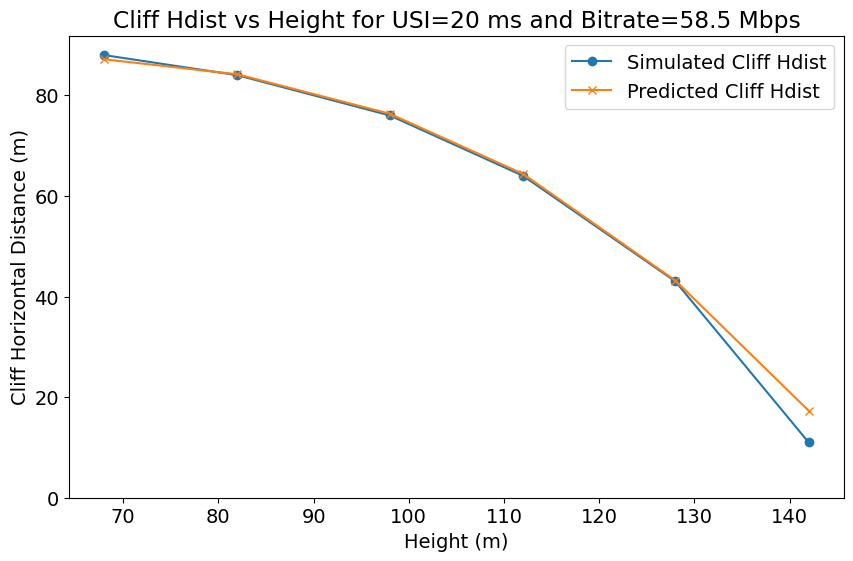

In [12]:
# Plot results
USI = 20
BITRATE = 58.5
subset_results = results_df[(results_df['USI'] == USI) & (results_df['Bitrate'] == BITRATE)]
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 14})
plt.plot(subset_results['Height'], subset_results['Ground Truth Cliff Hdist'], marker='o', label='Simulated Cliff Hdist')
plt.plot(subset_results['Height'], subset_results['Predicted Cliff Hdist'], marker='x', label='Predicted Cliff Hdist')
plt.title(f'Cliff Hdist vs Height for USI={USI} ms and Bitrate={BITRATE} Mbps')
plt.xlabel('Height (m)')
plt.ylabel('Cliff Horizontal Distance (m)')
plt.ylim(0)
plt.legend()

Text(0, 0.5, 'Frequency')

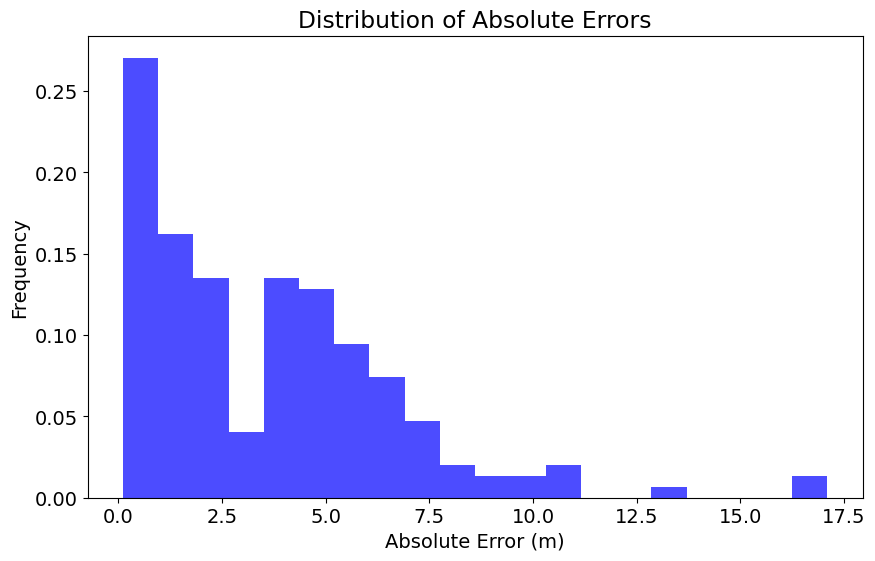

In [13]:
# Plot the abs error distribution
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 14})
plt.hist(abs_err, bins=20, density=True, color='blue', alpha=0.7)
plt.title('Distribution of Absolute Errors')
plt.xlabel('Absolute Error (m)')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

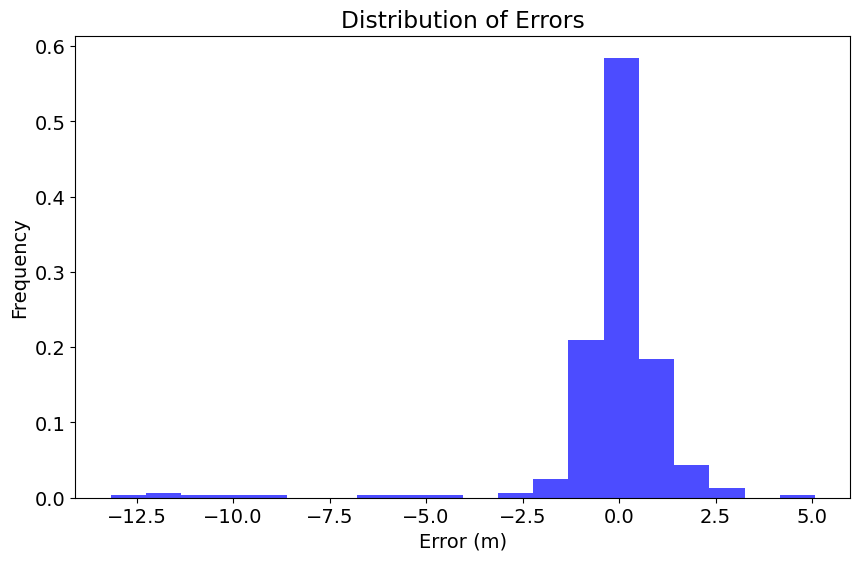

In [5]:
# Plot the error distribution. NOTE: Positive error means underestimation, negative error means overestimation
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 14})
plt.hist(err, bins=20, density=True, color='blue', alpha=0.7)
plt.title('Distribution of Errors')
plt.xlabel('Error (m)')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

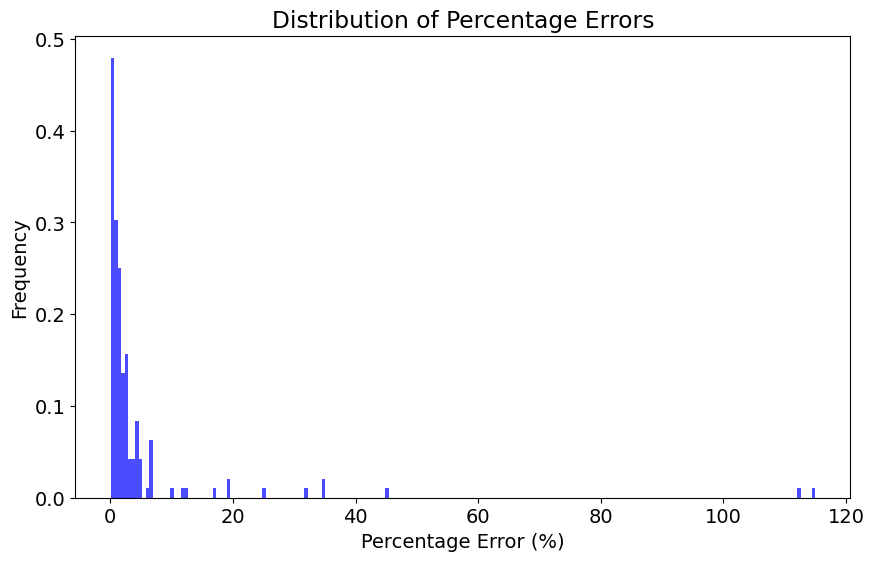

In [48]:
# Plot the percent error distribution
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 14})
plt.hist(percent_err, bins=200, density=True, color='blue', alpha=0.7)
plt.title('Distribution of Percentage Errors')
plt.xlabel('Percentage Error (%)')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

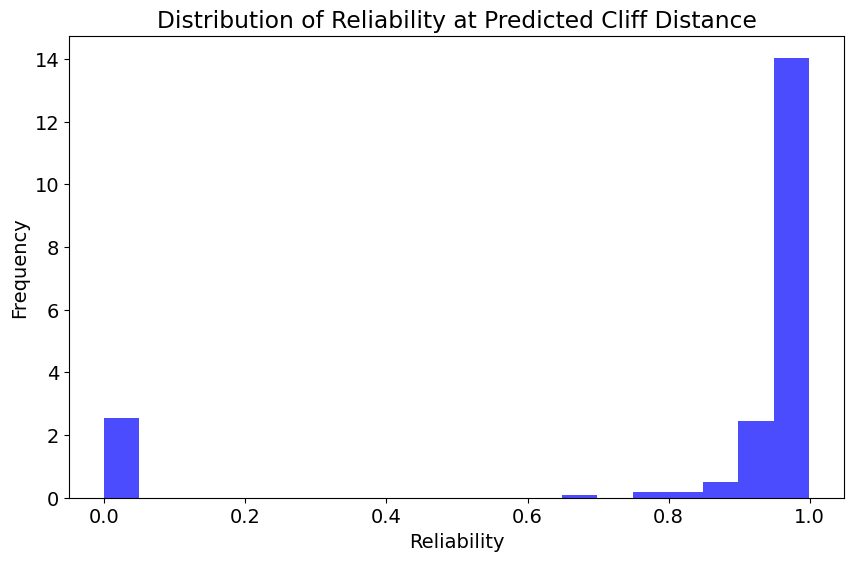

In [ ]:
# Plot the reliability at the (rounded up to nearest multiple of 10) cliff distance for each sample
test_dataset_file_path = (
    f"/media/research-student/DataDrive/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/test_dataset_processed/{link}_Reliability.csv"
)
test_data_df = add_reliability(pd.read_csv(test_dataset_file_path))

reliability_at_cliff = []
for idx, row in results_df.iterrows():
    usi = row["USI"]
    bitrate = row["Bitrate"]
    height = row["Height"]
    predicted_cliff_hdist = row["Predicted Cliff Hdist"]

    subset = test_data_df[
        (test_data_df["UAV_Sending_Interval"] == usi)
        & (test_data_df["Bitrate"] == bitrate)
        & (test_data_df["Height"] == height)
    ]

    if predicted_cliff_hdist > 0:
        # Find the reliability at the rounded up cliff distance to the nearest multiple of 10
        cliff_distance_rounded = int(np.ceil(predicted_cliff_hdist / 10.0) * 10)
        # cliff_distance_rounded = int(np.round(predicted_cliff_hdist / 10.0) * 10)
        reliability_row = subset[subset["Horizontal_Distance"] == cliff_distance_rounded]
        if not reliability_row.empty:
            reliability_at_cliff.append(reliability_row["Reliability"].values[0])
        
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 14})
plt.hist(reliability_at_cliff, bins=20, density=True, color='blue', alpha=0.7)
plt.title('Distribution of Reliability at Predicted Cliff Distance')
plt.xlabel('Reliability')
plt.ylabel('Frequency')

## Compare Plots for Training and Testing Data

In [12]:
link = "Uplink" # "Downlink", "Uplink", "Video"
USI = 10
BITRATE = 39
# TRAIN_HEIGHT = [60, 90, 120, 150, 180, 210, 240, 270, 300]
# TEST_HEIGHT = [75, 105, 135, 165, 195, 225, 255, 285]
TRAIN_HEIGHT = [60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285, 300]
TEST_HEIGHT = [68, 82, 98, 112, 128, 142, 158, 172, 188, 202, 218, 232, 248, 262, 278, 292]
# Training Dataset Path
train_dataset_file_path = f"/media/research-student/DataDrive/FANET_Dataset/Dataset_NP100000_DJISpark/refined_train_dataset_processed/{link}_Reliability.csv"
test_dataset_file_path = f"/media/research-student/DataDrive/FANET_Dataset/Dataset_NP100000_DJISpark/refined_test_dataset_processed/{link}_Reliability.csv"

train_df = pd.read_csv(train_dataset_file_path)
test_df = pd.read_csv(test_dataset_file_path)
cliff_dist_dict = {} 

if "Num_Sent" in train_df.columns and "Num_Reliable" in train_df.columns:
    train_df["Reliability"] = train_df["Num_Reliable"] / train_df["Num_Sent"]
    test_df["Reliability"] = test_df["Num_Reliable"] / test_df["Num_Sent"]
elif "Num_Fail_Other" in train_df.columns and "Num_Delay_Excd" in train_df.columns and "Num_Reliable" in train_df.columns:
    train_df["Reliability"] = train_df["Num_Reliable"] / (train_df["Num_Reliable"] + train_df["Num_Delay_Excd"] + train_df["Num_Fail_Other"])
    test_df["Reliability"] = test_df["Num_Reliable"] / (test_df["Num_Reliable"] + test_df["Num_Delay_Excd"] + test_df["Num_Fail_Other"])

train_cliff_hdist_list = []
for height in TRAIN_HEIGHT:
    subset = train_df[(train_df['UAV_Sending_Interval'] == USI) & (train_df['Bitrate'] == BITRATE) & (train_df['Height'] == height)]
    train_cliff_hdist_list.append(find_cliff_hdist(subset, threshold=0.99))

test_cliff_hdist_list = []
for height in TEST_HEIGHT:
    subset = test_df[(test_df['UAV_Sending_Interval'] == USI) & (test_df['Bitrate'] == BITRATE) & (test_df['Height'] == height)]
    test_cliff_hdist_list.append(find_cliff_hdist(subset, threshold=0.99))

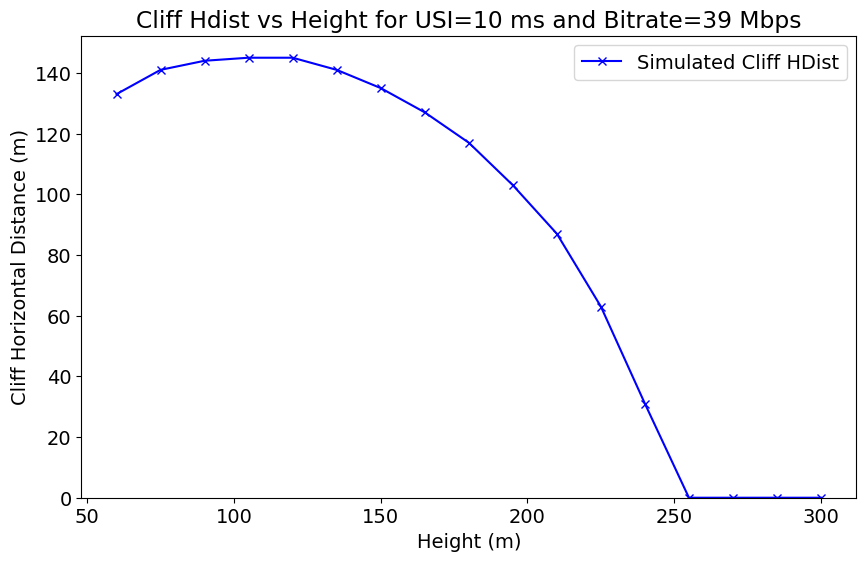

In [ ]:
# Plot the train and test data
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 14})
plt.plot(TRAIN_HEIGHT, train_cliff_hdist_list, 'b', marker='x', label='Simulated "Train" Cliff HDist')
plt.plot(TEST_HEIGHT, test_cliff_hdist_list, 'g', marker='o', label='Simulated "Test" Cliff HDist')
plt.title(f'Cliff Hdist vs Height for USI={USI} ms and Bitrate={BITRATE} Mbps')
plt.xlabel('Height (m)')
plt.ylabel('Cliff Horizontal Distance (m)')
plt.ylim(0)
plt.legend()

## Find Max Cliff Dist for Each USI

In [11]:
import numpy as np
import pandas as pd
from scipy.interpolate import make_interp_spline

# -------------------------------------------------
# Assumes find_cliff_hdist(df, threshold) exists
# -------------------------------------------------

def add_reliability(df: pd.DataFrame) -> pd.DataFrame:
    if "Num_Sent" in df.columns and "Num_Reliable" in df.columns:
        df["Reliability"] = df["Num_Reliable"] / df["Num_Sent"]
    elif all(c in df.columns for c in ["Num_Fail_Other", "Num_Delay_Excd", "Num_Reliable"]):
        denom = df["Num_Reliable"] + df["Num_Delay_Excd"] + df["Num_Fail_Other"]
        df["Reliability"] = df["Num_Reliable"] / denom
    else:
        raise ValueError("Required columns for Reliability not found.")
    return df

def combo_subset(df: pd.DataFrame, usi: float, bitrate: float, height: float) -> pd.DataFrame:
    # isclose is safer than exact float equality
    m_usi = np.isclose(df["UAV_Sending_Interval"].to_numpy(dtype=float), float(usi))
    m_bitrate = np.isclose(df["Bitrate"].to_numpy(dtype=float), float(bitrate))
    m_height = np.isclose(df["Height"].to_numpy(dtype=float), float(height))
    return df.loc[m_usi & m_bitrate & m_height]


# -----------------------------
# Config
# -----------------------------
link = "Video"  # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
TRAIN_HEIGHT = [60, 90, 120, 150, 180, 210, 240, 270, 300]
TEST_HEIGHT = [75, 105, 135, 165, 195, 225, 255, 285]
ALL_HEIGHT = sorted(set(TRAIN_HEIGHT) | set(TEST_HEIGHT))
THRESHOLD = 0.99

train_dataset_file_path = (
    f"/media/research-student/DataDrive/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/train_dataset_processed/{link}_Reliability.csv"
)
test_dataset_file_path = (
    f"/media/research-student/DataDrive/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/test_dataset_processed/{link}_Reliability.csv"
)

# -----------------------------
# Load and prepare data
# -----------------------------
train_df = add_reliability(pd.read_csv(train_dataset_file_path))
test_df = add_reliability(pd.read_csv(test_dataset_file_path))
overall_df = pd.concat([train_df, test_df], ignore_index=True)
# For each USI, get the max cliff distance acroos all heights and bitrates, and store in a dict for quick lookup during testing
cliff_dist_dict = {}
for usi in USI:
    for bitrate in BITRATE:
        for h in ALL_HEIGHT:
            subset = combo_subset(overall_df, usi, bitrate, h)
            cliff_hdist = find_cliff_hdist(subset, threshold=THRESHOLD)
            cliff_dist_dict[(usi, bitrate, h)] = cliff_hdist

cliff_dist_df = pd.DataFrame(
    [
        {"USI": usi, "Bitrate": bitrate, "Height": h, "Cliff_Hdist": cliff_dist_dict.get((usi, bitrate, h), np.nan)}
        for usi in USI
        for bitrate in BITRATE
        for h in ALL_HEIGHT
    ]
)

# Get max cliff distance for each USI
max_cliff_dist_dict = cliff_dist_df.groupby("USI")["Cliff_Hdist"].max().to_dict()
print("Max Cliff Distance per USI:")
for usi, max_dist in max_cliff_dist_dict.items():
    print(f"USI: {usi} ms, Max Cliff Distance: {max_dist:.2f} m")   

# Now do the same but for each Bitrate
max_cliff_dist_bitrate_dict = cliff_dist_df.groupby("Bitrate")["Cliff_Hdist"].max().to_dict()
print("\nMax Cliff Distance per Bitrate:")
for bitrate, max_dist in max_cliff_dist_bitrate_dict.items():
    print(f"Bitrate: {bitrate} Mbps, Max Cliff Distance: {max_dist:.2f} m")

Max Cliff Distance per USI:
USI: 10.0 ms, Max Cliff Distance: 200.00 m
USI: 20.0 ms, Max Cliff Distance: 430.00 m
USI: 66.7 ms, Max Cliff Distance: 540.00 m
USI: 100.0 ms, Max Cliff Distance: 570.00 m

Max Cliff Distance per Bitrate:
Bitrate: 6.5 Mbps, Max Cliff Distance: 570.00 m
Bitrate: 13.0 Mbps, Max Cliff Distance: 520.00 m
Bitrate: 19.5 Mbps, Max Cliff Distance: 390.00 m
Bitrate: 26.0 Mbps, Max Cliff Distance: 270.00 m
Bitrate: 39.0 Mbps, Max Cliff Distance: 190.00 m
Bitrate: 52.0 Mbps, Max Cliff Distance: 120.00 m
Bitrate: 58.5 Mbps, Max Cliff Distance: 100.00 m
Bitrate: 65.0 Mbps, Max Cliff Distance: 120.00 m


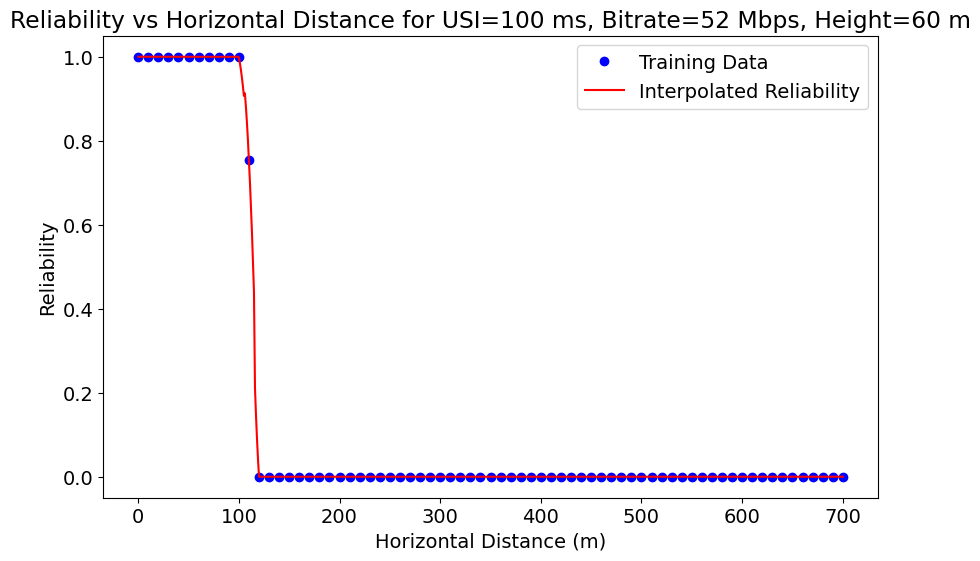

In [17]:
link = "Uplink"  # "Downlink", "Uplink", "Video"
USI = [100]
BITRATE = [52]
TRAIN_HEIGHT = [60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285, 300]
TEST_HEIGHT = [68, 82, 98, 112, 128, 142, 158, 172, 188, 202, 218, 232, 248, 262, 278, 292]
THRESHOLD = 0.99
K_NEIGHBORS_RELIABILITY = 3 # for finding cliff distance from reliability curve
K_NEIGHBORS_CLIFF = 3 # for local spline prediction of cliff distance from neighboring cliff distances

train_dataset_file_path = (
    f"/media/research-student/DataDrive/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/new_train_dataset_processed/{link}_Reliability.csv"
)

df = pd.read_csv(train_dataset_file_path)
df = add_reliability(df)
subset = combo_subset(df, USI[0], BITRATE[0], TRAIN_HEIGHT[0])
df_refine = interp_reliability(subset, k_points=3)

# Plot Horizontal_Distance vs Reliability for the original and refined data
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 14})
plt.plot(subset["Horizontal_Distance"], subset["Reliability"], 'bo', label='Training Data')
plt.plot(df_refine["Horizontal_Distance"], df_refine["Reliability"], 'r-', label='Interpolated Reliability')
plt.title(f'Reliability vs Horizontal Distance for USI={USI[0]} ms, Bitrate={BITRATE[0]} Mbps, Height={TRAIN_HEIGHT[0]} m')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Reliability')
plt.legend()
plt.show()

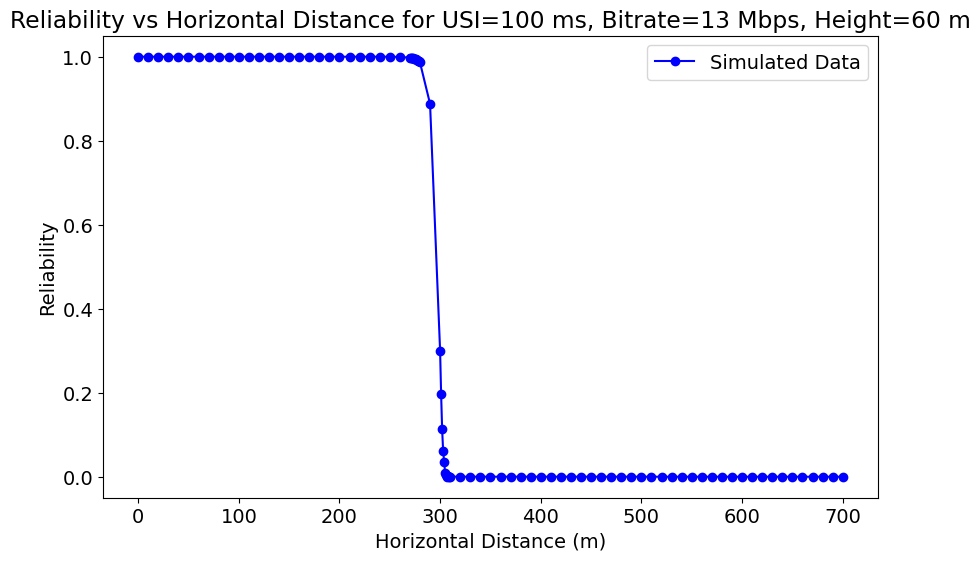

In [3]:
def add_reliability(df: pd.DataFrame) -> pd.DataFrame:
    if "Num_Sent" in df.columns and "Num_Reliable" in df.columns:
        df["Reliability"] = df["Num_Reliable"] / df["Num_Sent"]
    elif all(c in df.columns for c in ["Num_Fail_Other", "Num_Delay_Excd", "Num_Reliable"]):
        denom = df["Num_Reliable"] + df["Num_Delay_Excd"] + df["Num_Fail_Other"]
        df["Reliability"] = df["Num_Reliable"] / denom
    else:
        raise ValueError("Required columns for Reliability not found.")
    return df

def combo_subset(df: pd.DataFrame, usi: float, bitrate: float, height: float) -> pd.DataFrame:
    # isclose is safer than exact float equality
    m_usi = np.isclose(df["UAV_Sending_Interval"].to_numpy(dtype=float), float(usi))
    m_bitrate = np.isclose(df["Bitrate"].to_numpy(dtype=float), float(bitrate))
    m_height = np.isclose(df["Height"].to_numpy(dtype=float), float(height))
    return df.loc[m_usi & m_bitrate & m_height]

link = "Uplink"  # "Downlink", "Uplink", "Video"
USI = [100]
BITRATE = [13]
TRAIN_HEIGHT = [60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285, 300]
TEST_HEIGHT = [68, 82, 98, 112, 128, 142, 158, 172, 188, 202, 218, 232, 248, 262, 278, 292]
THRESHOLD = 0.99

train_dataset_file_path = (
    f"/media/research-student/DataDrive/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/refined_train_dataset_processed/{link}_Reliability.csv"
)

df = pd.read_csv(train_dataset_file_path)
df = add_reliability(df)
subset = combo_subset(df, USI[0], BITRATE[0], TRAIN_HEIGHT[0])
# df_refine = interp_reliability(subset, k_points=3)

# Plot Horizontal_Distance vs Reliability for the original and refined data
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 14})
plt.plot(subset["Horizontal_Distance"], subset["Reliability"], 'bo-', label='Simulated Data')
# plt.plot(df_refine["Horizontal_Distance"], df_refine["Reliability"], 'r-', label='Interpolated Reliability')
plt.title(f'Reliability vs Horizontal Distance for USI={USI[0]} ms, Bitrate={BITRATE[0]} Mbps, Height={TRAIN_HEIGHT[0]} m')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Reliability')
plt.legend()
plt.show()